In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

## Plant-Health-Data
https://www.kaggle.com/datasets/ziya07/plant-health-data/data

### Key Features:
Timestamp: The date and time of each biosensor reading.
1. Plant_ID: Unique identifier for each plant in the dataset.
2. Soil_Moisture (%): Measures the water content in soil, crucial for maintaining adequate hydration levels.
3. Ambient_Temperature (°C): Ambient temperature around the plant.
4. Soil_Temperature (°C): Soil temperature near plant roots.
5. Humidity (%): Air humidity level, which affects plant transpiration and growth.
6. Light_Intensity (Lux): Measures light exposure, essential for photosynthesis.
7. Soil_pH: Indicates the acidity or alkalinity of the soil, affecting nutrient availability.
8. Nitrogen_Level (mg/kg): Key nutrient supporting plant growth and leaf development.
9. Phosphorus_Level (mg/kg): Nutrient important for root and flower development.
10. Potassium_Level (mg/kg): Nutrient aiding in overall plant resilience and disease resistance.
11. Chlorophyll_Content (mg/m²): Chlorophyll concentration reflects photosynthetic activity and plant health.
12. Electrochemical_Signal (mV): Represents stress signals detected in plants, often due to environmental changes or internal stress responses.

**Plant_Health_Status**[TARGET]: Categorical label indicating the overall health of the plant, based on soil moisture and nutrient levels. It has three possible values:
- Healthy
- Moderate Stress
- High Stress

In [3]:
df = pd.read_csv("./plant_health_data.csv")

In [4]:
df.head()

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [5]:
df.shape

(1200, 14)

In [6]:
df.isnull().sum() # Check Null Values

Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

In [7]:
# Check Duplicated Values
df.duplicated().sum()

np.int64(0)

In [8]:
# Data Summarize
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), int64(1), object(2)
memo

In [9]:
# Statistical Summary of Numerical Columns
df.describe()

,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,5.500000,25.106918,23.999130,19.957794,54.853165,612.637265,6.524102,30.106751,30.264484,30.112088,34.749591,0.987764
std,2.873479,8.677725,3.441561,2.932073,8.784916,228.318853,0.581755,11.514396,11.466846,11.668085,8.766995,0.575116
min,1.000000,10.000724,18.001993,15.003710,40.028758,200.615482,5.507392,10.003650,10.017690,10.000606,20.025511,0.002376
25%,3.000000,17.131893,21.101766,17.353027,47.019694,416.878983,6.026042,20.249774,20.894445,19.585561,27.463350,0.487982
50%,5.500000,25.168333,23.889044,19.911473,54.692069,617.240221,6.540524,30.138590,30.019385,30.495054,34.433427,0.981647
75%,8.000000,32.370231,27.042634,22.596851,62.451053,811.474690,7.030039,40.184737,40.131459,40.108296,42.232637,1.473142
max,10.000000,39.993164,29.990886,24.995929,69.968871,999.856262,7.497823,49.951136,49.980700,49.981945,49.990811,1.996116


In [10]:
# Check Correlation of Numerical Columns
df.corr(numeric_only=True)

,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal
Plant_ID,1.000000,-0.034321,-0.029856,0.023195,-0.004697,0.008830,0.046939,-0.020165,-0.011265,0.016812,-0.008191,-0.005156
Soil_Moisture,-0.034321,1.000000,-0.009344,-0.026783,0.053876,-0.009343,-0.043502,-0.024752,0.019002,0.030804,0.039419,-0.010556
Ambient_Temperature,-0.029856,-0.009344,1.000000,0.037381,0.003921,-0.025289,-0.021229,-0.012223,-0.001462,0.011405,0.027442,0.007278
Soil_Temperature,0.023195,-0.026783,0.037381,1.000000,0.022697,0.004004,-0.025315,-0.033010,-0.039818,-0.025599,0.050740,-0.023506
Humidity,-0.004697,0.053876,0.003921,0.022697,1.000000,-0.023648,0.013627,-0.022661,-0.003064,0.012435,0.019202,0.007398
Light_Intensity,0.008830,-0.009343,-0.025289,0.004004,-0.023648,1.000000,0.008377,-0.012746,-0.040853,-0.029557,0.017122,-0.003094
Soil_pH,0.046939,-0.043502,-0.021229,-0.025315,0.013627,0.008377,1.000000,-0.006345,0.023200,0.011618,0.001404,-0.021791
Nitrogen_Level,-0.020165,-0.024752,-0.012223,-0.033010,-0.022661,-0.012746,-0.006345,1.000000,0.013319,0.007934,-0.045398,-0.003875
Phosphorus_Level,-0.011265,0.019002,-0.001462,-0.039818,-0.003064,-0.040853,0.023200,0.013319,1.000000,-0.022126,0.001347,-0.010935
Potassium_Level,0.016812,0.030804,0.011405,-0.025599,0.012435,-0.029557,0.011618,0.007934,-0.022126,1.000000,-0.010863,-0.013052


In [11]:
# Check Columns Name
df.columns

Index(['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature',
       'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH',
       'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level',
       'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status'],
      dtype='object')

In [12]:
# Check Dtypes of Columns
df.dtypes

Timestamp                  object
Plant_ID                    int64
Soil_Moisture             float64
Ambient_Temperature       float64
Soil_Temperature          float64
Humidity                  float64
Light_Intensity           float64
Soil_pH                   float64
Nitrogen_Level            float64
Phosphorus_Level          float64
Potassium_Level           float64
Chlorophyll_Content       float64
Electrochemical_Signal    float64
Plant_Health_Status        object
dtype: object

In [13]:
# See Correlation Matrix
correlation_matrix = df.corr(numeric_only=True)

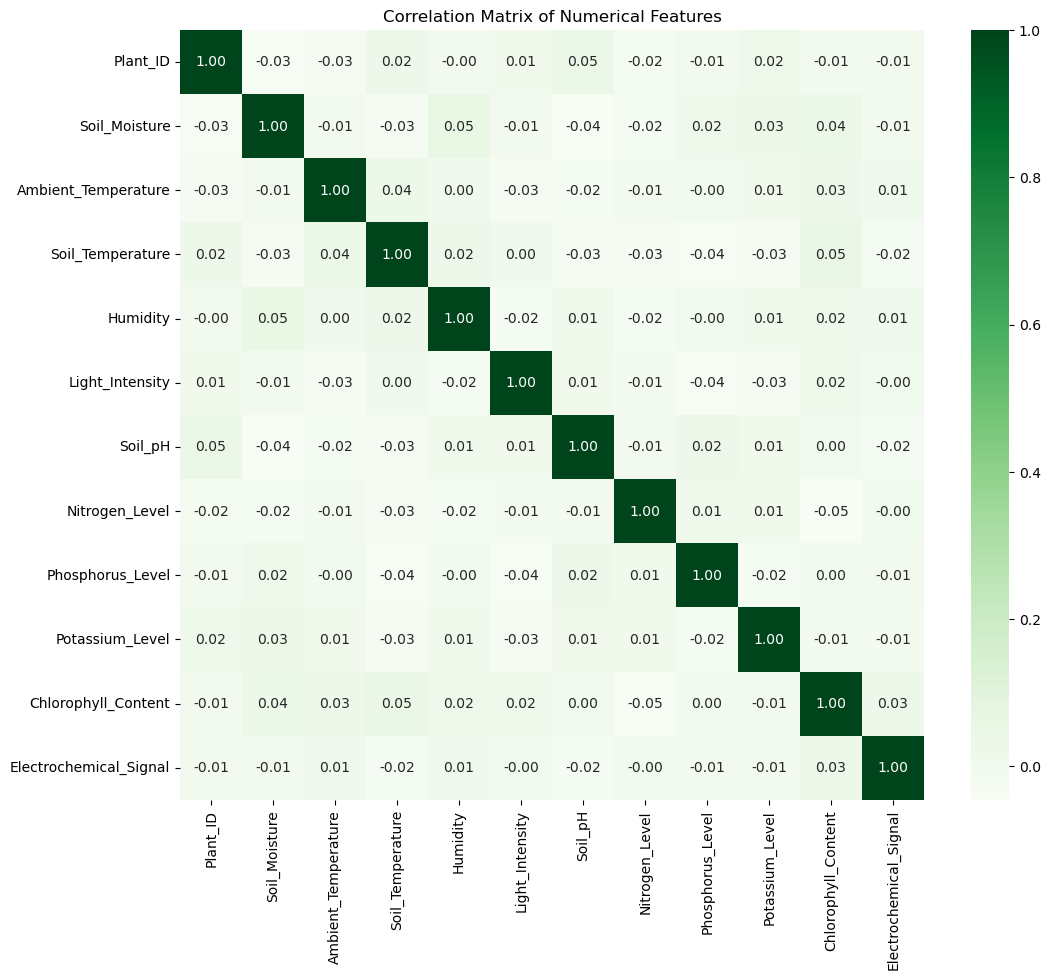

In [14]:
#  No  major correlation between columns variables
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

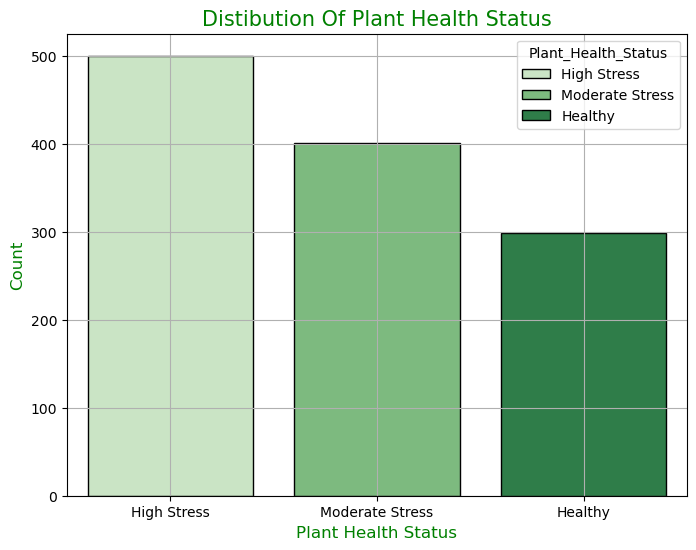

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(x=df['Plant_Health_Status'], hue=df['Plant_Health_Status'],
              palette='Greens', edgecolor='black', legend=True)
plt.title('Distibution Of Plant Health Status', fontsize=15, color='green')
plt.xlabel('Plant Health Status', fontsize=12, color='green')
plt.ylabel('Count', fontsize=12, color='green')
plt.grid()
plt.show()

In [16]:
cols = ['Soil_Moisture', 'Ambient_Temperature',
       'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH',
       'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level',
       'Chlorophyll_Content', 'Electrochemical_Signal']

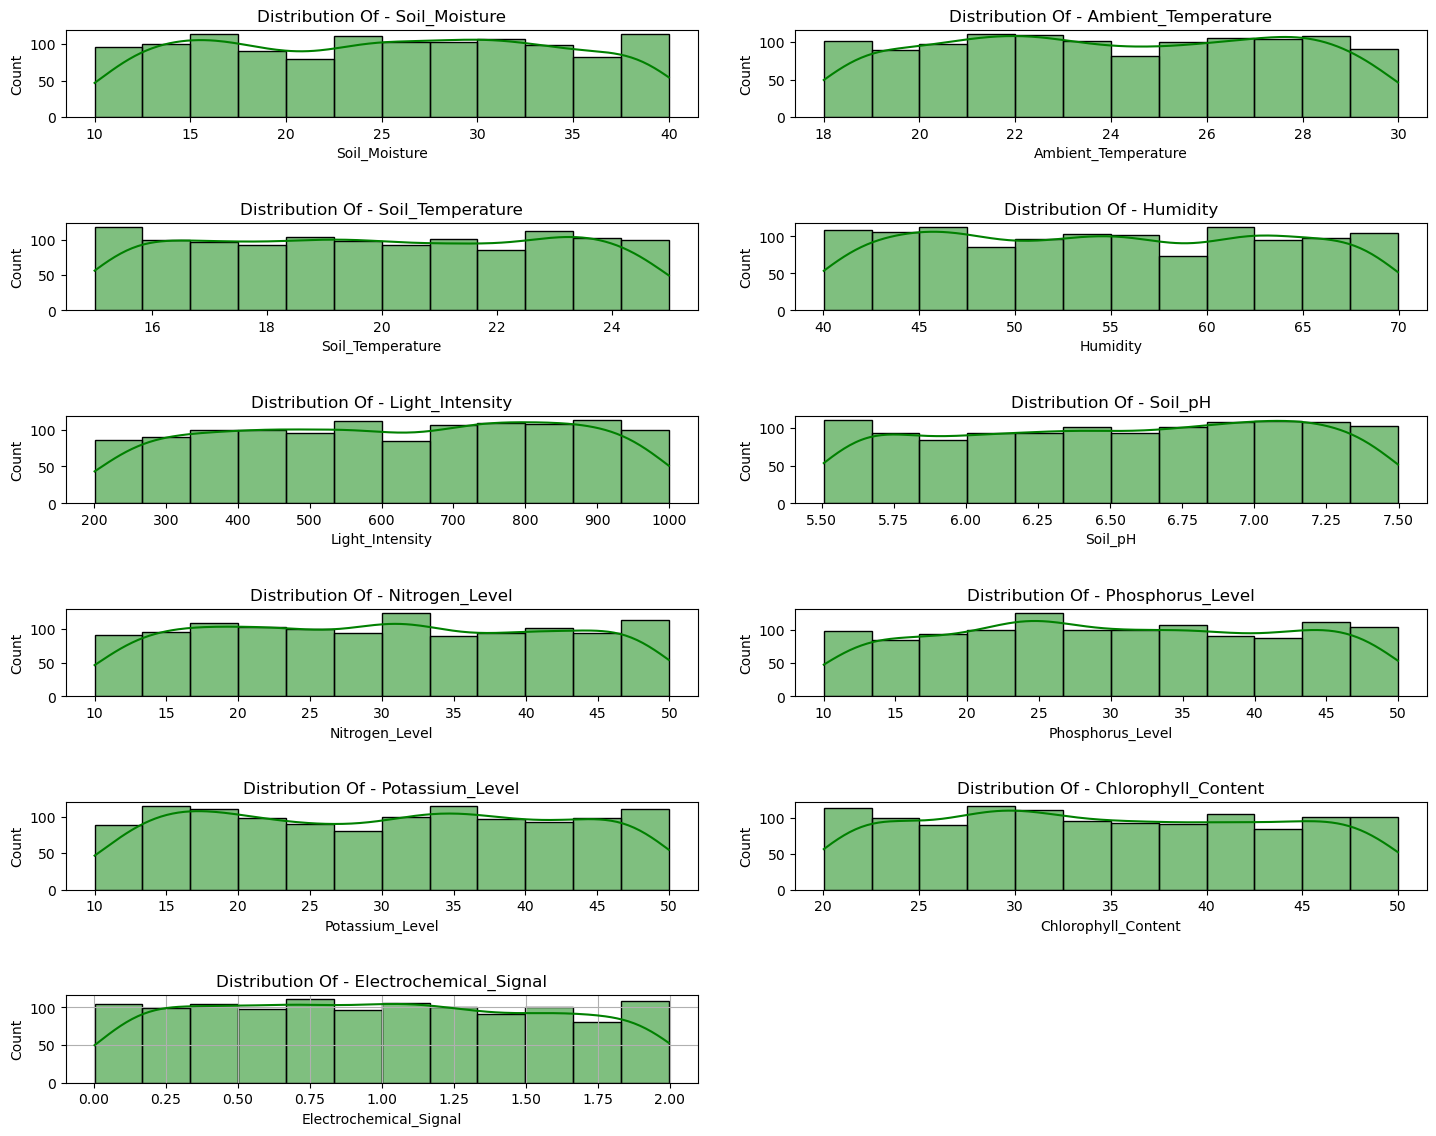

In [17]:
## Distribution of Variables
plt.figure(figsize=(15,12))
for k, col in enumerate(cols):
    plt.subplot(6, 2, k+1)
    sns.histplot(x=col, data=df, kde=True, color='green')
    plt.title(f"Distribution Of - {col}", color='black')
plt.tight_layout(pad=3.0)
plt.grid()
plt.show()

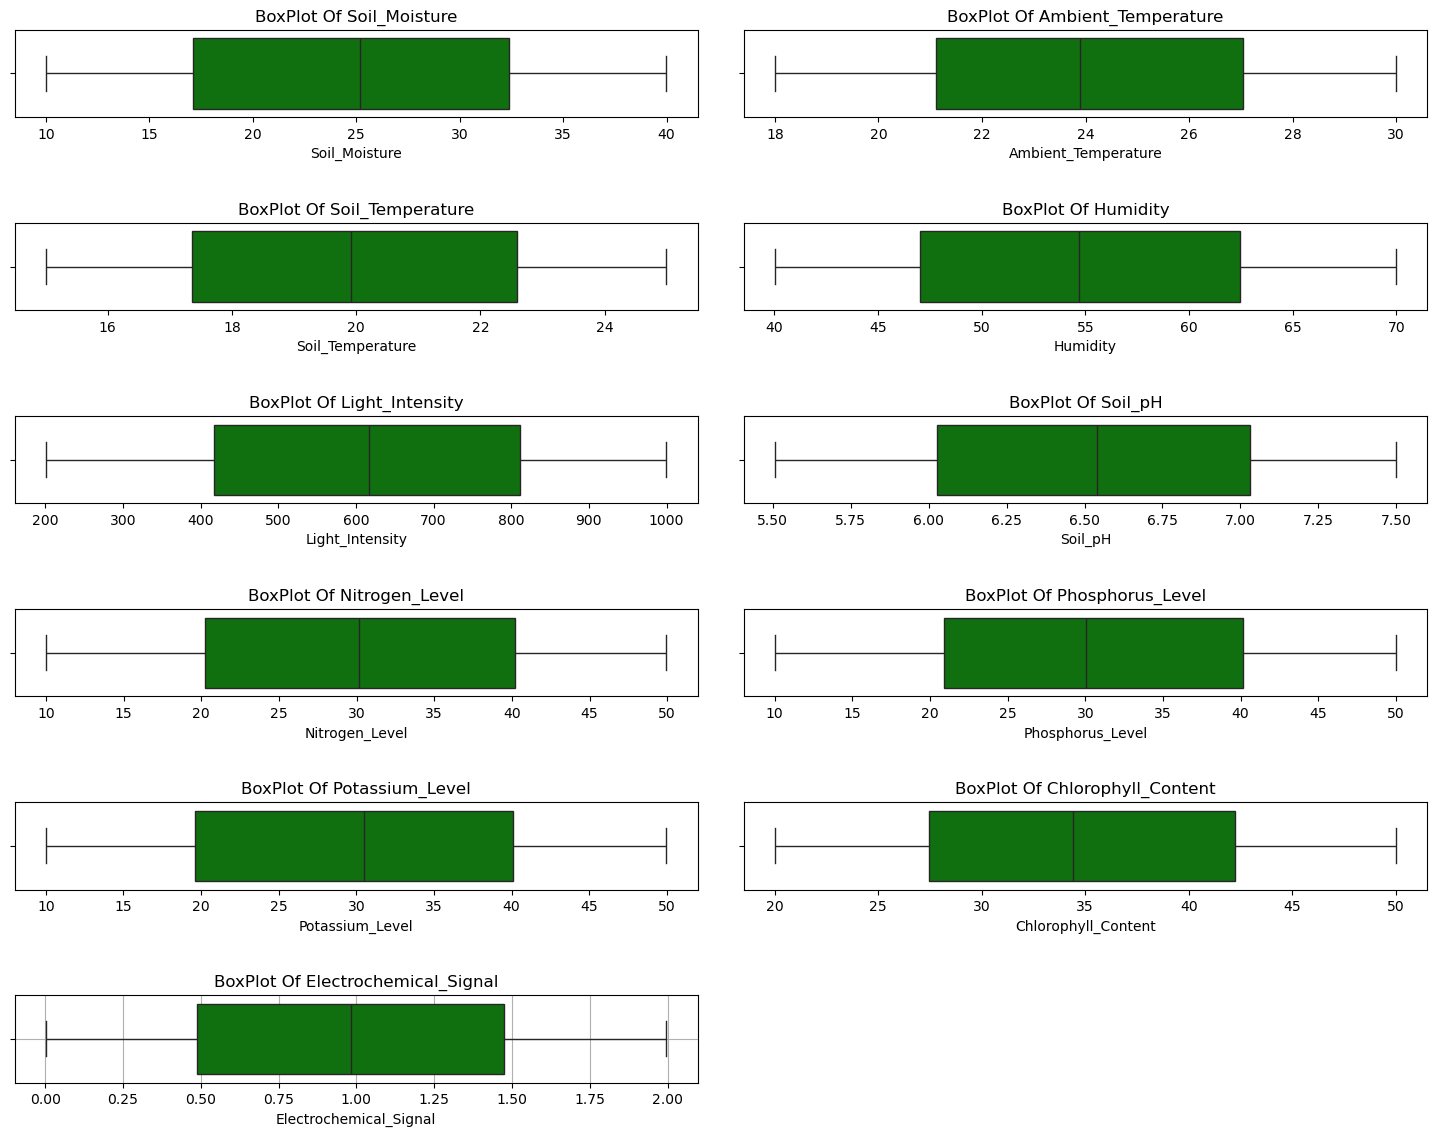

In [18]:
# Stats
plt.figure(figsize=(15,12))
for k, col in enumerate(cols):
    plt.subplot(6, 2, k+1)
    sns.boxplot(x=col, data=df, color='green')
    plt.title(f"BoxPlot Of {col}", color='black')
plt.tight_layout(pad=3.0)
plt.grid()
plt.show()

## Label Encoding

In [19]:
encoder = LabelEncoder()
df['Plant_Health_Status'] =  encoder.fit_transform(df['Plant_Health_Status'])

In [20]:
X= df[cols]

In [21]:
y  =  df["Plant_Health_Status"]

In [22]:
# Random seed
RANDOM_STATE = 42

In [23]:
# SPLIT DATASET
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.15, random_state=RANDOM_STATE)

In [24]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (1020, 11)
X_test Shape: (180, 11)
y_train Shape: (1020,)
y_test Shape: (180,)


## Build ML Model

In [25]:
model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
preds = model.predict(X_test)

In [27]:
score = accuracy_score(y_test, preds)
pre = precision_score(y_test, preds, average='macro')

In [28]:
print(f'Accuracy Score : {round(score,3)}')
print(f'Precision Score: {round(pre,3)}')

Accuracy Score : 0.994
Precision Score: 0.995


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      0.98      0.99        61
           2       0.98      1.00      0.99        65

    accuracy                           0.99       180
   macro avg       0.99      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180



## Confusion Matrix

In [30]:
cm = confusion_matrix(y_test, preds)

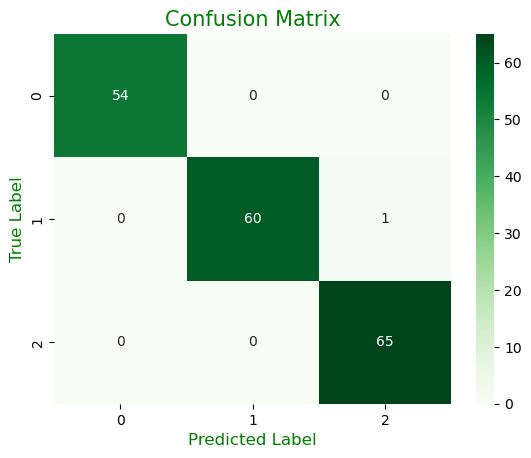

In [31]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix', color='green', fontsize=15)
plt.xlabel('Predicted Label', color='green', fontsize=12)
plt.ylabel('True Label', color='green', fontsize=12)
plt.show()

In [32]:
import json

In [33]:
# Get the original class names from the LabelEncoder
class_names = encoder.classes_

In [34]:
# Create a dictionary to store the class mapping
class_mapping = {i: name for i, name in enumerate(class_names)}


In [35]:
json_file_path = './plant_health_classes.json'

In [36]:
# Save the dictionary to a JSON file
with open(json_file_path, 'w') as json_file:
    json.dump(class_mapping, json_file, indent=4)

In [37]:
print(f"Target class mapping saved to '{json_file_path}'")
print("Class Mapping:", class_mapping)

Target class mapping saved to './plant_health_classes.json'
Class Mapping: {0: 'Healthy', 1: 'High Stress', 2: 'Moderate Stress'}


In [38]:
import joblib

joblib.dump(model, './plant_health_model.joblib')
print("Model saved as 'plant_health_model.joblib' in ./ml")

Model saved as 'plant_health_model.joblib' in ./ml
